# 05. Comparison & Latent Space Interpolation

- FID summary table across all three models
- Latent interpolation strips (10 images each)
- Cats vs. Cats+Dogs comparison (exploratory extension)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import yaml
import pandas as pd
from IPython.display import Image as IPImage

from src.utils.seed import set_seed
from src.utils.visualization import show_interpolation_strip
from src.evaluation.interpolation import (
    interpolation_strip, lerp, slerp, dcgan_interpolation, vqvae_interpolation, ddpm_interpolation
)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
results = [
    {'Model': 'DCGAN',   'FID': 221.51, 'Notes': 'z_dim=128, WGAN-GP, 100 epochs'},
    {'Model': 'VQ-VAE',  'FID': 187.54, 'Notes': 'K=512, D=64, PixelCNN prior'},
    {'Model': 'DDPM',    'FID': 24.36,  'Notes': 'T=1000, DDIM 50 steps, 200 epochs'},
]
df = pd.DataFrame(results)
print(df.to_markdown(index=False))

| Model   |    FID | Notes                             |
|:--------|-------:|:----------------------------------|
| DCGAN   | 221.51 | z_dim=128, WGAN-GP, 100 epochs    |
| VQ-VAE  | 187.54 | K=512, D=64, PixelCNN prior       |
| DDPM    |  24.36 | T=1000, DDIM 50 steps, 200 epochs |


DCGAN interpolation strip saved to ../outputs/dcgan/interpolation.png


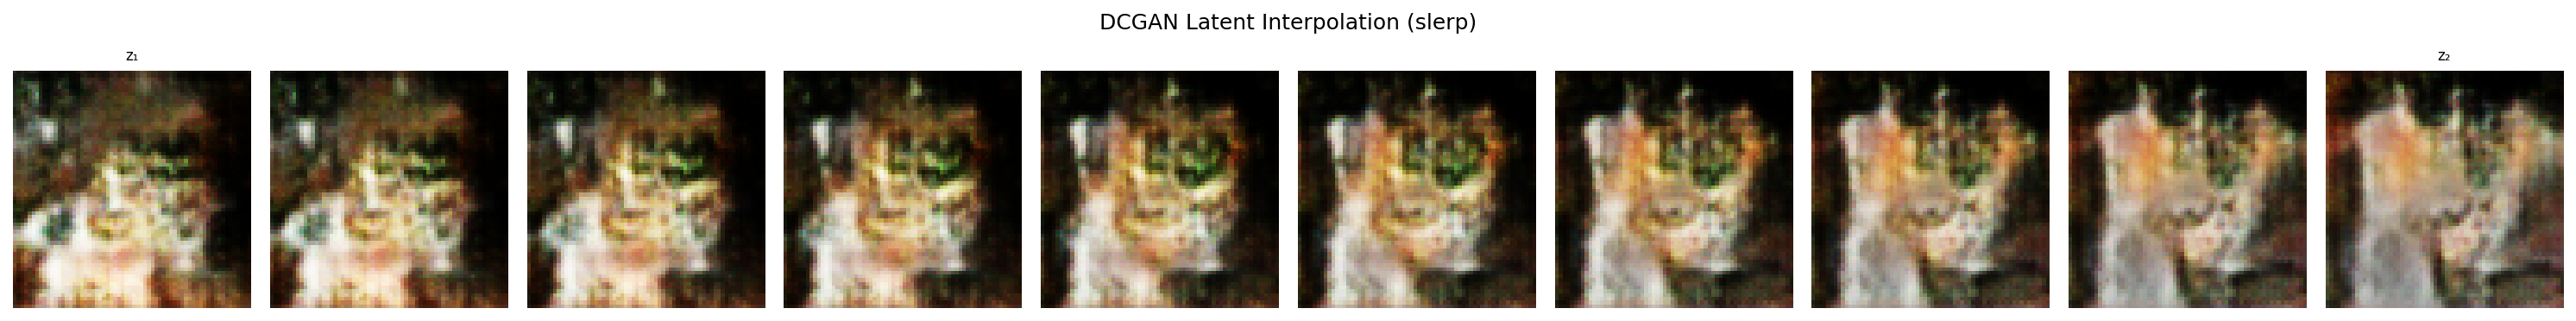

In [3]:
dcgan_interpolation(
    checkpoint='../checkpoints/dcgan/ckpt_epoch0100.pt',
    cfg=yaml.safe_load(open('../configs/dcgan_config.yaml', encoding='utf-8')),
    out='../outputs/dcgan/interpolation.png',
    device=device,
)
IPImage('../outputs/dcgan/interpolation.png')

VQ-VAE interpolation strip saved to ../outputs/vqvae/interpolation.png


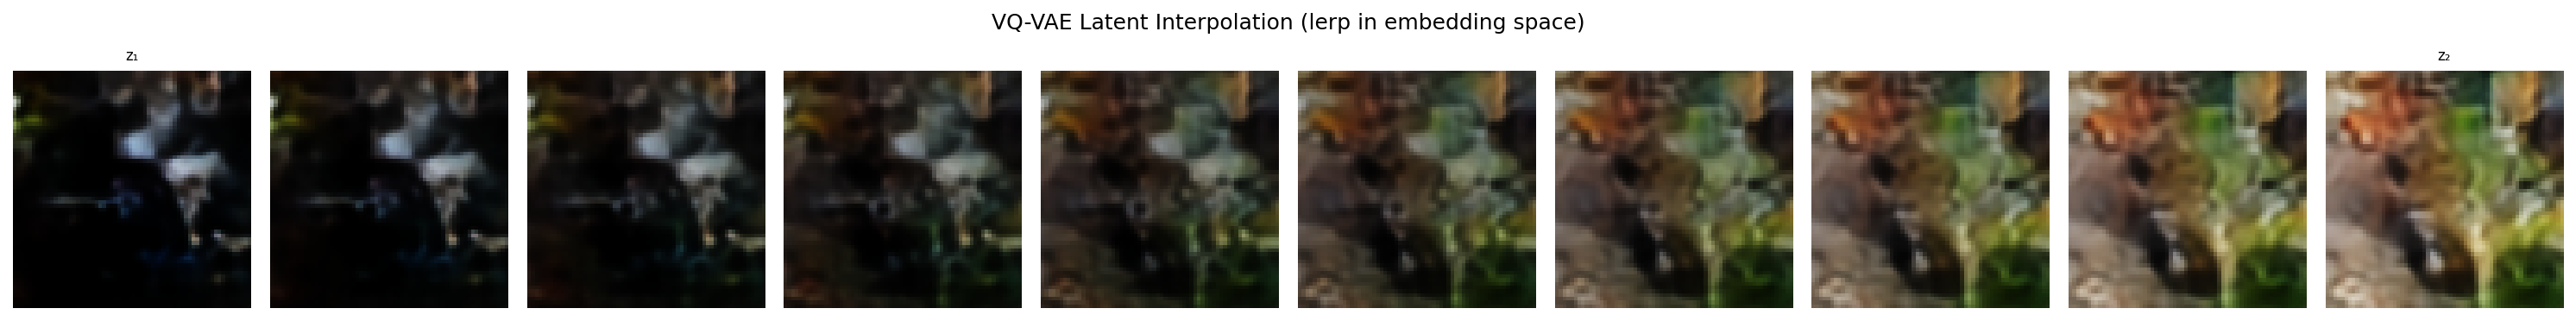

In [4]:
vqvae_interpolation(
    checkpoint='../checkpoints/vqvae/vqvae_epoch0100.pt',
    prior_ckpt='../checkpoints/vqvae/prior_epoch0100.pt',
    cfg=yaml.safe_load(open('../configs/vqvae_config.yaml', encoding='utf-8')),
    out='../outputs/vqvae/interpolation.png',
    device=device,
)
IPImage('../outputs/vqvae/interpolation.png')

DDPM interpolation strip saved to ../outputs/ddpm/interpolation.png


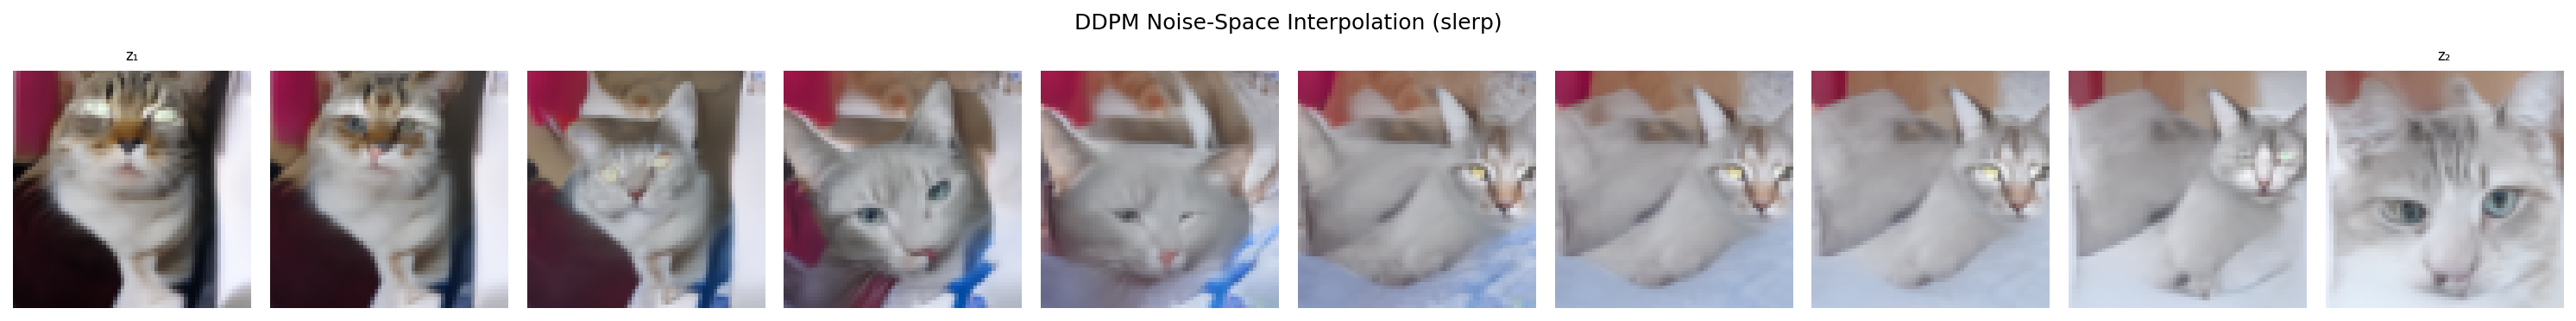

In [5]:
ddpm_interpolation(
    checkpoint='../checkpoints/ddpm/ddpm_epoch0200.pt',
    cfg=yaml.safe_load(open('../configs/ddpm_config.yaml', encoding='utf-8')),
    out='../outputs/ddpm/interpolation.png',
    device=device,
)
IPImage('../outputs/ddpm/interpolation.png')

In [6]:
import json
import pandas as pd

with open('../outputs/cats_and_dogs/fid_results.json') as f:
    cd = json.load(f)

mixed_results = [
    {'Model': 'DCGAN (cats only, 100 ep.)',    'FID vs Cats': 221.51, 'FID vs Dogs': 'N/A'},
    {'Model': 'DCGAN (cats+dogs, 100 ep.)',    'FID vs Cats': round(cd['fid_vs_cats'], 2), 'FID vs Dogs': round(cd['fid_vs_dogs'], 2)},
]
df2 = pd.DataFrame(mixed_results)
print(df2.to_markdown(index=False))

| Model                      |   FID vs Cats | FID vs Dogs   |
|:---------------------------|--------------:|:--------------|
| DCGAN (cats only, 100 ep.) |        221.51 | —             |
| DCGAN (cats+dogs, 100 ep.) |        206.57 | 197.79        |
